In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sales_electroprima.csv')
df.head()

,transaction_id,date,branch,product_category,product_name,unit_price,quantity_sold,total_sales,payment_method,customer_gender,customer_age,satisfaction_rating,promo_status,daily_ad_spend
0,TRX01409,2026-01-01,Surabaya,Laptop,Laptop A14,14493000,1,14493000,E-Wallet,M,57.0,NaN,Regular,584000
1,TRX00846,2026-01-01,Bandung,Smartphone,Smartphone MaxEdge,7967000,5,39835000,Credit Card,M,21.0,NaN,Regular,1652000
2,TRX01550,2026-01-01,Jakarta,Accessories,Wireless Mouse,126000,4,504000,Cash,F,33.0,5.0,Regular,1092000
3,TRX01622,2026-01-01,Jakarta,Laptop,Laptop X1,13021000,3,39063000,Credit Card,F,39.0,1.0,Regular,727000
4,TRX01996,2026-01-01,Malang,Smartphone,Smartphone NovaLite,5472000,2,10944000,Credit Card,F,41.0,4.0,Regular,1630000


In [10]:
df['branch'].value_counts()

branch
Malang      682
Surabaya    653
Jakarta     529
Bandung     336
Name: count, dtype: int64

In [11]:
pd.crosstab(df['branch'], df['product_category'])

product_category,Accessories,Home Appliances,Laptop,Smartphone
branch,,,,
Bandung,88,44,77,127
Jakarta,128,74,134,193
Malang,160,106,184,232
Surabaya,147,87,174,245


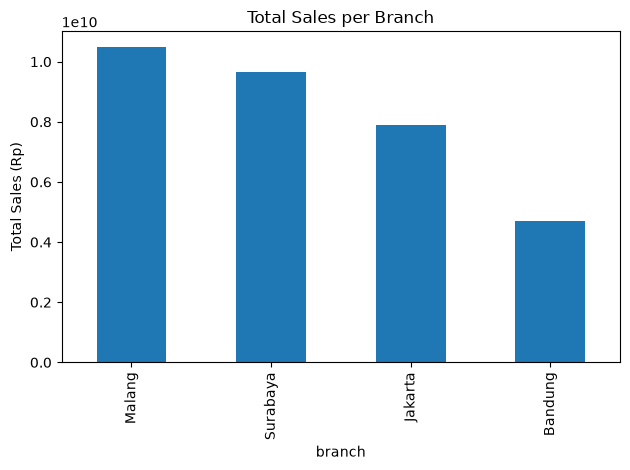

In [12]:
df.groupby('branch')['total_sales'].sum().sort_values(ascending=False).plot(
    kind='bar', title='Total Sales per Branch')
plt.ylabel('Total Sales (Rp)')
plt.tight_layout()
plt.show()

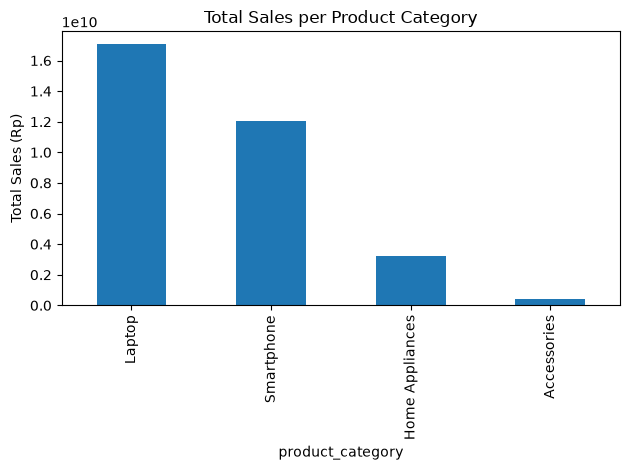

In [13]:
df.groupby('product_category')['total_sales'].sum().sort_values(ascending=False).plot(
    kind='bar', title='Total Sales per Product Category')
plt.ylabel('Total Sales (Rp)')
plt.tight_layout()
plt.show()


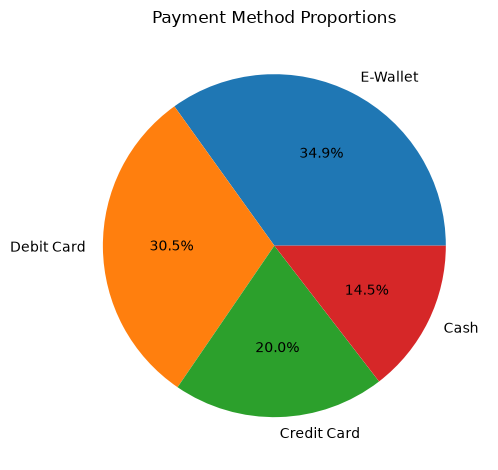

In [14]:
df['payment_method'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', title='Payment Method Proportions')
plt.ylabel('')
plt.tight_layout()
plt.show()

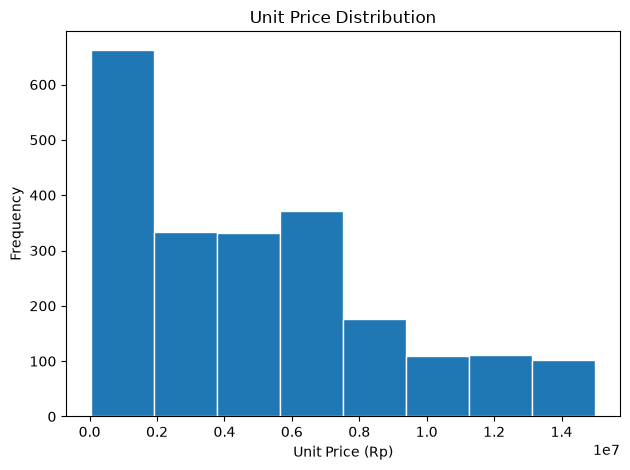

In [15]:
df['unit_price'].plot(kind='hist', bins=8, edgecolor='white',
    title='Unit Price Distribution')
plt.xlabel('Unit Price (Rp)')
plt.tight_layout()
plt.show()

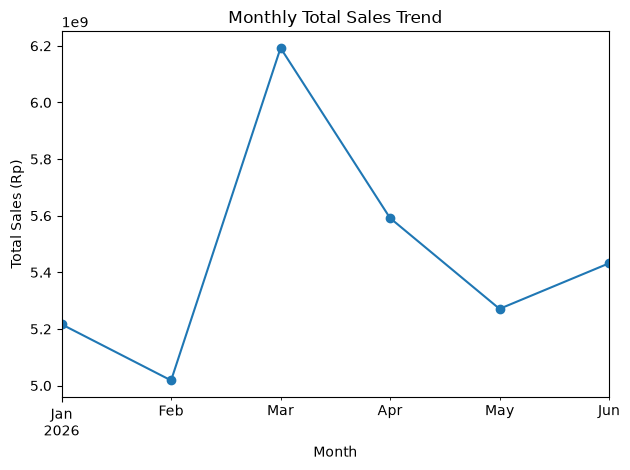

In [16]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
df.groupby('month')['total_sales'].sum().plot(
    kind='line', marker='o', title='Monthly Total Sales Trend')
plt.ylabel('Total Sales (Rp)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

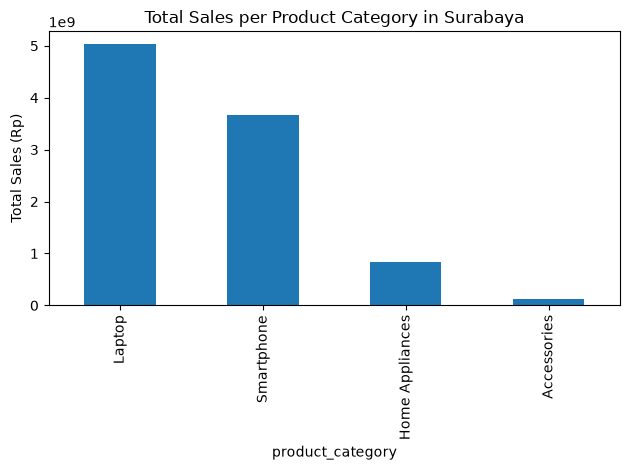

In [18]:
df_surabaya = df[df['branch']=='Surabaya']
df_surabaya.groupby('product_category')['total_sales'].sum().sort_values(ascending=False).plot(
    kind='bar', title='Total Sales per Product Category in Surabaya')
plt.ylabel('Total Sales (Rp)')
plt.tight_layout()
plt.show()

In [19]:
bins = [0, 20, 40, 60, 80]
labels = ['0-20', '20-40', '40-60', '60-80']
df['age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels, right=False)
print(df['age_group'].value_counts().sort_index())

age_group
0-20      122
20-40    1437
40-60     505
60-80       4
Name: count, dtype: int64


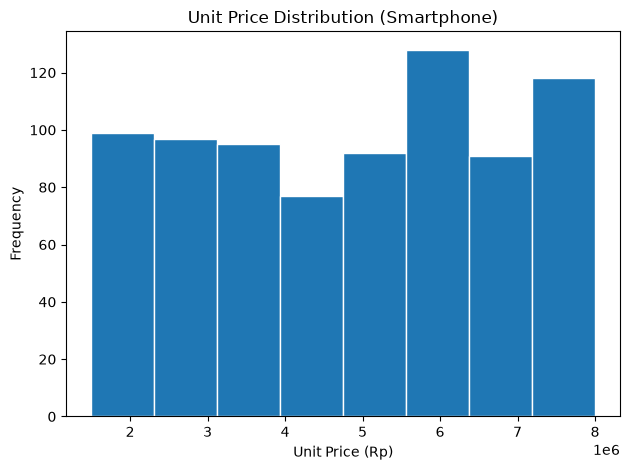

In [21]:
df_smartphone = df[df['product_category'] == 'Smartphone']
df_smartphone['unit_price'].plot(kind='hist', bins=8, edgecolor='white',
    title='Unit Price Distribution (Smartphone)')
plt.xlabel('Unit Price (Rp)')
plt.tight_layout()
plt.show()